<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/RNN_LSTM_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 時系列予測 ─ 正弦波の学習

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────
# データの準備: 正弦波の時系列予測
# ──────────────────────────────
def create_sine_data(n_samples=1000, seq_len=50, pred_len=1):
    """正弦波から入力系列と予測対象を生成"""
    t = np.linspace(0, 20 * np.pi, n_samples + seq_len + pred_len)
    data = np.sin(t)

    X, y = [], []
    for i in range(n_samples):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len : i + seq_len + pred_len])

    X = np.array(X, dtype=np.float32)   # (n_samples, seq_len)
    y = np.array(y, dtype=np.float32)   # (n_samples, pred_len)
    return X, y

X_all, y_all = create_sine_data(n_samples=2000, seq_len=50)

# 訓練 / テスト分割
split = 1600
X_train, y_train = X_all[:split], y_all[:split]
X_test, y_test = X_all[split:], y_all[split:]

# PyTorch テンソルに変換: (batch, seq_len, input_size=1)
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t = torch.FloatTensor(y_test)

print(f"X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")
# X_train: (1600, 50, 1), y_train: (1600, 1)


X_train: torch.Size([1600, 50, 1]), y_train: torch.Size([1600, 1])


## 基本 RNN モデル

In [2]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True          # 入力を (batch, seq, feature) の形式で受け取る
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, h_n = self.rnn(x)
        # out: (batch, seq_len, hidden_size) — 全時刻の隠れ状態
        # h_n: (num_layers, batch, hidden_size) — 最終時刻の隠れ状態
        out = self.fc(out[:, -1, :])   # 最終時刻の隠れ状態のみ使用
        return out

model_rnn = SimpleRNN(hidden_size=64, num_layers=1)
print(model_rnn)
print(f"パラメータ数: {sum(p.numel() for p in model_rnn.parameters()):,}")


SimpleRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
パラメータ数: 4,353


## LSTMモデル

In [3]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)
        # h_n: (num_layers, batch, hidden_size)
        # c_n: (num_layers, batch, hidden_size) — LSTM 固有のセル状態
        out = self.fc(out[:, -1, :])
        return out

model_lstm = LSTMPredictor(hidden_size=64, num_layers=2, dropout=0.2)
print(model_lstm)
print(f"パラメータ数: {sum(p.numel() for p in model_lstm.parameters()):,}")


LSTMPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
パラメータ数: 50,497


## GRUモデル

In [4]:
class GRUPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

model_gru = GRUPredictor(hidden_size=64, num_layers=2, dropout=0.2)
print(model_gru)
print(f"パラメータ数: {sum(p.numel() for p in model_gru.parameters()):,}")


GRUPredictor(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
パラメータ数: 37,889


## 学習ループと 3 モデルの比較


=== Vanilla RNN の学習 ===
  最終テスト MSE: 0.000028, パラメータ数: 4,353

=== LSTM の学習 ===
  最終テスト MSE: 0.000166, パラメータ数: 50,497

=== GRU の学習 ===
  最終テスト MSE: 0.000012, パラメータ数: 37,889


/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3062412782.py:59: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  p

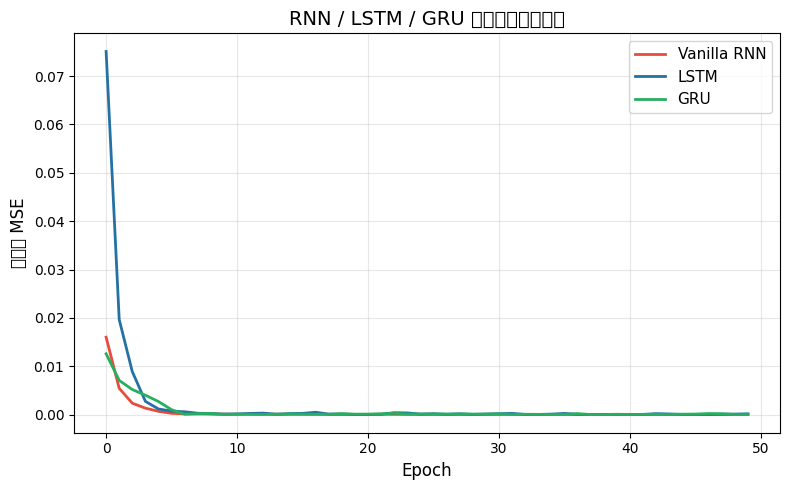

In [5]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

def train_model(model, train_dl, X_test_t, y_test_t, n_epochs=50, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in train_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        train_losses.append(epoch_loss / len(train_ds))

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t.to(device))
            test_loss = criterion(test_pred, y_test_t.to(device)).item()
        test_losses.append(test_loss)

    return train_losses, test_losses

# 3 モデルの学習
results = {}
for name, model in [('Vanilla RNN', SimpleRNN(hidden_size=64)),
                      ('LSTM', LSTMPredictor(hidden_size=64, num_layers=2)),
                      ('GRU', GRUPredictor(hidden_size=64, num_layers=2))]:
    print(f"\n=== {name} の学習 ===")
    tr_losses, te_losses = train_model(model, train_dl, X_test_t, y_test_t, n_epochs=50)
    results[name] = {
        'model': model, 'train_losses': tr_losses, 'test_losses': te_losses
    }
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  最終テスト MSE: {te_losses[-1]:.6f}, パラメータ数: {n_params:,}")

# 学習曲線の比較
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Vanilla RNN': '#E74C3C', 'LSTM': '#2471A3', 'GRU': '#27AE60'}
for name, res in results.items():
    ax.plot(res['test_losses'], linewidth=2, color=colors[name], label=name)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('テスト MSE', fontsize=12)
ax.set_title('RNN / LSTM / GRU のテスト損失比較', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_comparison.png', dpi=150)
plt.show()


## 予測結果の可視化

/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 24358 (\N{CJK UNIFIED IDEOGRAPH-5F26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:18: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/1978653975.py:19: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missi

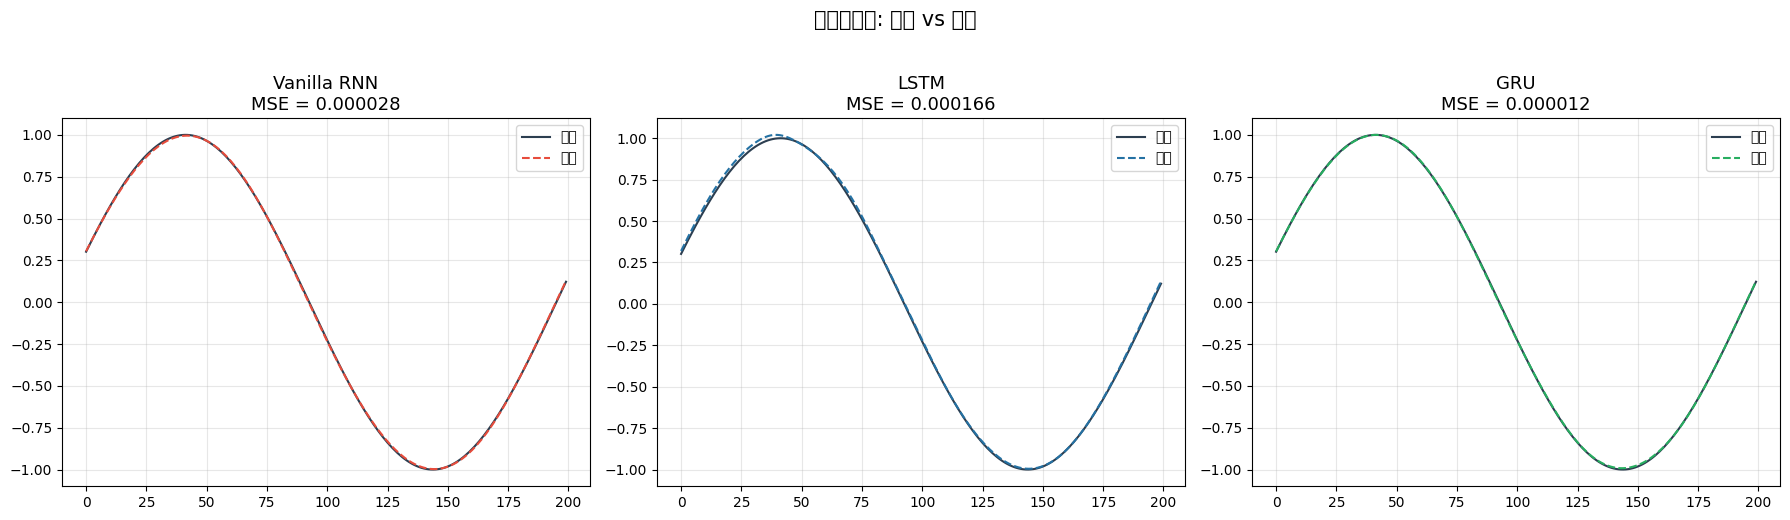

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    model = res['model']
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t.to(device)).cpu().numpy().flatten()

    ax.plot(y_test.flatten()[:200], linewidth=1.5, label='正解', color='#2C3E50')
    ax.plot(preds[:200], linewidth=1.5, label='予測', color=colors[name], linestyle='--')
    ax.set_title(f'{name}\nMSE = {res["test_losses"][-1]:.6f}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('正弦波予測: 正解 vs 予測', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('rnn_predictions.png', dpi=150)
plt.show()


## テキスト分類 ─ LSTM による感情分析

In [7]:
import string
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

# ──────────────────────────────
# 簡易データセットの作成（デモ用）
# ──────────────────────────────
positive_texts = [
    "this movie is great", "i love this film", "wonderful acting and story",
    "amazing movie experience", "really enjoyed the film", "fantastic plot",
    "excellent performances", "best movie ever", "beautiful cinematography",
    "great characters and story", "highly recommended film", "superb acting",
] * 20
negative_texts = [
    "this movie is terrible", "i hate this film", "worst movie ever",
    "boring and dull story", "awful acting", "waste of time",
    "really bad experience", "terrible plot", "horrible performances",
    "worst film i have seen", "very disappointing movie", "awful waste",
] * 20

texts = positive_texts + negative_texts
labels = [1] * len(positive_texts) + [0] * len(negative_texts)

# ── 語彙の構築 ──
def tokenize(text):
    return text.lower().translate(str.maketrans('', '', string.punctuation)).split()

word_counts = Counter(w for t in texts for w in tokenize(t))
vocab = {w: i+2 for i, (w, _) in enumerate(word_counts.most_common(500))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode(text, vocab, max_len=20):
    tokens = tokenize(text)[:max_len]
    return [vocab.get(w, vocab['<UNK>']) for w in tokens]

# ── テンソルへの変換 ──
encoded = [torch.LongTensor(encode(t, vocab)) for t in texts]
padded = pad_sequence(encoded, batch_first=True, padding_value=0)
labels_t = torch.FloatTensor(labels)

# 訓練 / テスト分割
indices = torch.randperm(len(padded))
split_idx = int(0.8 * len(padded))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_tr_text, y_tr_text = padded[train_idx], labels_t[train_idx]
X_te_text, y_te_text = padded[test_idx], labels_t[test_idx]

print(f"語彙サイズ: {len(vocab)}, 系列長: {padded.shape[1]}")
print(f"訓練: {len(X_tr_text)}, テスト: {len(X_te_text)}")


語彙サイズ: 45, 系列長: 5
訓練: 384, テスト: 96


## テキスト分類用 LSTM モデル

In [8]:
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64,
                 num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len) — 単語インデックスの系列
        embedded = self.embedding(x)       # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(embedded)
        # 最終層の最終時刻の隠れ状態
        hidden = h_n[-1]                   # (batch, hidden_size)
        hidden = self.dropout(hidden)
        logit = self.fc(hidden).squeeze(-1)  # (batch,)
        return logit

text_model = TextLSTM(vocab_size=len(vocab), embed_dim=32, hidden_size=64)
print(text_model)

# ── 学習 ──
criterion_text = nn.BCEWithLogitsLoss()
optimizer_text = optim.Adam(text_model.parameters(), lr=0.001)

text_ds = TensorDataset(X_tr_text, y_tr_text)
text_dl = DataLoader(text_ds, batch_size=32, shuffle=True)

for epoch in range(20):
    text_model.train()
    total_loss = 0
    for Xb, yb in text_dl:
        logits = text_model(Xb)
        loss = criterion_text(logits, yb)
        optimizer_text.zero_grad()
        loss.backward()
        optimizer_text.step()
        total_loss += loss.item() * len(yb)

    if (epoch+1) % 5 == 0:
        text_model.eval()
        with torch.no_grad():
            test_logits = text_model(X_te_text)
            test_preds = (torch.sigmoid(test_logits) > 0.5).float()
            acc = (test_preds == y_te_text).float().mean().item()
        print(f"Epoch {epoch+1:2d}: Loss={total_loss/len(text_ds):.4f}, Test Acc={acc:.4f}")

# ── 新しいテキストで推論 ──
text_model.eval()
test_sentences = ["this film is amazing", "terrible waste of time", "really great movie"]
for sent in test_sentences:
    enc = torch.LongTensor([encode(sent, vocab)]).to(next(text_model.parameters()).device)
    with torch.no_grad():
        prob = torch.sigmoid(text_model(enc)).item()
    label = "Positive" if prob > 0.5 else "Negative"
    print(f"  \"{sent}\" → {label} (p={prob:.4f})")


TextLSTM(
  (embedding): Embedding(45, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Epoch  5: Loss=0.3713, Test Acc=0.9375
Epoch 10: Loss=0.0055, Test Acc=1.0000
Epoch 15: Loss=0.0028, Test Acc=1.0000
Epoch 20: Loss=0.0016, Test Acc=1.0000
  "this film is amazing" → Positive (p=0.9983)
  "terrible waste of time" → Negative (p=0.0009)
  "really great movie" → Positive (p=0.9872)


## 双方向 LSTM

In [9]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers=1,
            batch_first=True,
            bidirectional=True       # 双方向を有効化
        )
        # 双方向なので hidden_size × 2
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        out, (h_n, c_n) = self.lstm(embedded)
        # h_n: (2, batch, hidden_size) — 順方向と逆方向
        # 両方向の最終隠れ状態を結合
        hidden = torch.cat([h_n[0], h_n[1]], dim=1)  # (batch, hidden_size*2)
        logit = self.fc(hidden).squeeze(-1)
        return logit

bi_model = BiLSTMClassifier(vocab_size=len(vocab))
print(f"双方向 LSTM パラメータ数: {sum(p.numel() for p in bi_model.parameters()):,}")
print(f"単方向 LSTM パラメータ数: {sum(p.numel() for p in text_model.parameters()):,}")


双方向 LSTM パラメータ数: 51,745
単方向 LSTM パラメータ数: 26,593


## 隠れ状態の時間変化の可視化}

/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278/3272639827.py:29: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missi

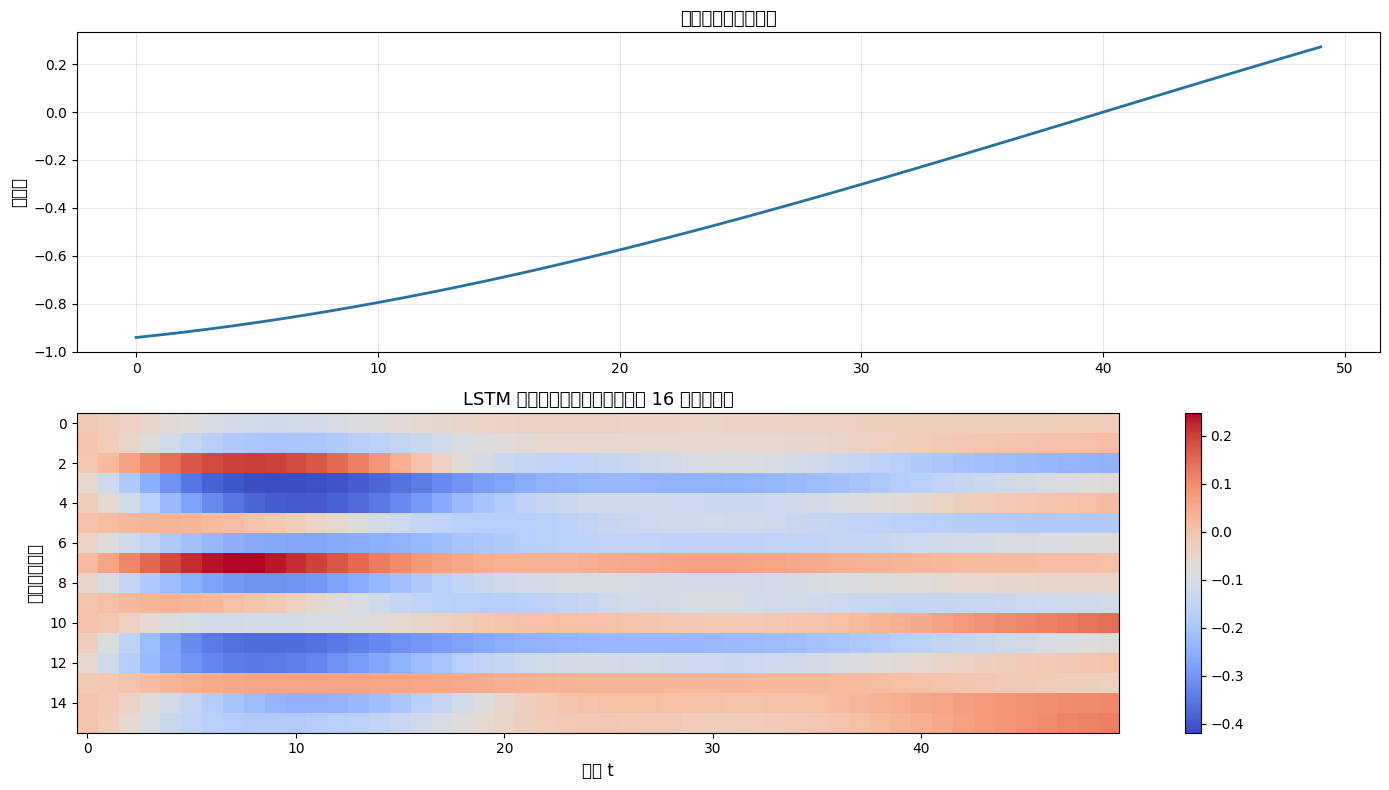

In [10]:
# 正弦波データで LSTM の隠れ状態の変化を可視化
lstm_model = results['LSTM']['model']
lstm_model.eval()

# 1 サンプルの順伝播で全時刻の隠れ状態を取得
sample = X_test_t[0:1].to(device)  # (1, 50, 1)
with torch.no_grad():
    out, (h_n, c_n) = lstm_model.lstm(sample)
    # out: (1, 50, 64) — 各時刻の隠れ状態

hidden_states = out.cpu().squeeze(0).numpy()  # (50, 64)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 入力系列
axes[0].plot(X_test[0], linewidth=2, color='#2471A3')
axes[0].set_ylabel('入力値', fontsize=12)
axes[0].set_title('入力系列（正弦波）', fontsize=13)
axes[0].grid(True, alpha=0.3)

# 隠れ状態のヒートマップ（先頭 16 ユニット）
im = axes[1].imshow(hidden_states[:, :16].T, aspect='auto', cmap='coolwarm',
                     interpolation='nearest')
axes[1].set_xlabel('時刻 t', fontsize=12)
axes[1].set_ylabel('隠れユニット', fontsize=12)
axes[1].set_title('LSTM 隠れ状態の時間変化（先頭 16 ユニット）', fontsize=13)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('rnn_hidden_states.png', dpi=150)
plt.show()
